In [ ]:
#Lab 3. Logistic Regression
#Given a suitable classification dataset:
#a) Identify the input features and target variable and split the dataset into training and testing sets.
#b) Build and train a Logistic Regression model.
#c) Explain the role of the sigmoid function in converting the model output into probability.
#d) Predict class labels and class probabilities for the test data and explain the role of the classification threshold.
#e) Evaluate the model using a confusion matrix and suitable classification measures.
#f) Plot the ROC curve and calculate AUC, where applicable.
#g) Change the classification threshold, observe its effect on predictions, and use the trained model to classify a new observation.


In [2]:
#a) Identify the input features and target variable and split the dataset into training and testing sets.

import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("02_loan_approval.csv")

# Input features (X) = all columns except the target column
X = df.drop("loan_approved", axis=1)

# Target variable (y) = loan_approved
# 0 = Loan not approved
# 1 = Loan approved
y = df["loan_approved"]

# Convert categorical columns into numbers
# Logistic Regression works with numerical data
X = pd.get_dummies(X, drop_first=True)

# Split the data into training and testing data
# 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Display the shapes
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 12)
Testing data: (60, 12)


In [3]:
#b) Build and train a Logistic Regression model.

from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model using training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [4]:
#c) Explain the role of the sigmoid function in converting the model output into probability.

# Logistic Regression uses the Sigmoid function.
# It converts the model's output into a probability between 0 and 1.
# Example:
# Probability close to 1 -> higher chance of loan approval
# Probability close to 0 -> lower chance of loan approval

# Get probabilities for the test data
probabilities = model.predict_proba(X_test)

# Display first 5 probability results
print("Probabilities:")
print(probabilities[:5])

Probabilities:
[[0.80140019 0.19859981]
 [0.58238924 0.41761076]
 [0.22926492 0.77073508]
 [0.76879771 0.23120229]
 [0.69146166 0.30853834]]


In [5]:
#d) Predict class labels and class probabilities for the test data and explain the role of the classification threshold.

# Predict class labels
# 0 = Loan not approved
# 1 = Loan approved
y_pred = model.predict(X_test)

# Get probability of loan approval
# [:, 1] selects probability of class 1
y_prob = model.predict_proba(X_test)[:, 1]

print("Predicted class labels:")
print(y_pred[:10])

print("\nProbability of loan approval:")
print(y_prob[:10])

# Classification threshold
# Default threshold is 0.50
# If probability >= 0.50 -> predict 1
# If probability < 0.50 -> predict 0

threshold = 0.50

threshold_predictions = (y_prob >= threshold).astype(int)

print("\nPredictions using threshold 0.50:")
print(threshold_predictions[:10])

Predicted class labels:
[0 0 1 0 0 1 1 0 1 0]

Probability of loan approval:
[0.19859981 0.41761076 0.77073508 0.23120229 0.30853834 0.69057471
 0.60188908 0.14549566 0.69022542 0.49372737]

Predictions using threshold 0.50:
[0 0 1 0 0 1 1 0 1 0]


In [6]:
#e) Evaluate the model using a confusion matrix and suitable classification measures.

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision
precision = precision_score(y_test, y_pred)

# Calculate recall
recall = recall_score(y_test, y_pred)

# Calculate F1-score
f1 = f1_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Confusion Matrix:
[[22  6]
 [12 20]]

Accuracy: 0.7
Precision: 0.7692307692307693
Recall: 0.625
F1-Score: 0.6896551724137931


AUC Score: 0.7935267857142857


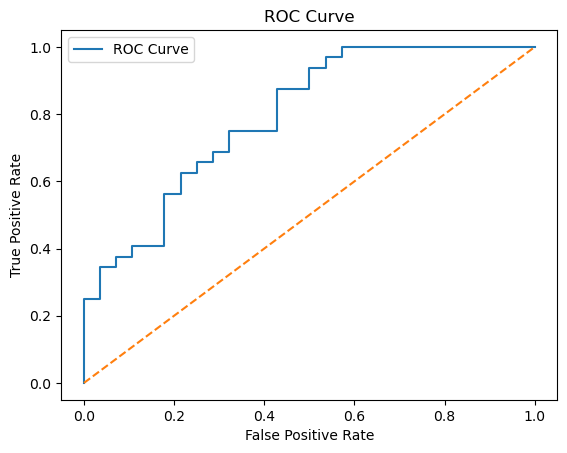

In [7]:
#f) Plot the ROC curve and calculate AUC, where applicable.

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC score
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

# Plot ROC curve
plt.plot(fpr, tpr, label="ROC Curve")

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [8]:
#g) Change the classification threshold, observe its effect on predictions, and use the trained model to classify a new observation.

# Change the threshold from 0.50 to 0.70
# Higher threshold means probability must be higher
# to classify the loan as approved (1)

new_threshold = 0.70

new_threshold_predictions = (y_prob >= new_threshold).astype(int)

print("Predictions using threshold 0.70:")
print(new_threshold_predictions[:10])


# Classify a new loan applicant
# Example values are given according to the dataset columns

new_applicant = pd.DataFrame({
    "annual_income_thousand_usd": [80],
    "credit_score": [700],
    "debt_to_income_pct": [25],
    "employment_years": [10],
    "employment_type": ["Full-time"],
    "region": ["South"],
    "marital_status": ["Single"]
})

# Convert categorical values into numerical columns
new_applicant = pd.get_dummies(new_applicant, drop_first=True)

# Make sure new applicant has exactly the same columns as training data
new_applicant = new_applicant.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Find probability of loan approval
new_probability = model.predict_proba(new_applicant)[0][1]

# Use 0.50 threshold for final prediction
new_prediction = int(new_probability >= 0.50)

print("\nNew Applicant Probability:", new_probability)
print("New Applicant Prediction:", new_prediction)

# 0 = Loan not approved
# 1 = Loan approved


Predictions using threshold 0.70:
[0 0 1 0 0 0 0 0 0 0]

New Applicant Probability: 0.6961053558955329
New Applicant Prediction: 1
